In [72]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from tqdm import tqdm
import json
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
plt.style.use('dark_background')
print("Using device : ",device)

Using device :  cuda


In [73]:
# Paths
NOTEBOOK_DIR = Path().resolve()
BASE_DIR = NOTEBOOK_DIR.parents[1]
SEG_DATASET_DIR = BASE_DIR / "data" / "raw" / "kvasir-seg" / "Kvasir-SEG"
INPUT_DIR = SEG_DATASET_DIR / "images"
TARGET_DIR = SEG_DATASET_DIR / "masks"
MODEL_OUTPUT_DIR = BASE_DIR / "models" / "8-pranet"
MODEL_OUTPUT_DIR.mkdir(exist_ok=True, parents=True)
HEIGHT , WIDTH = 256 , 256
IMAGE_SIZE = (HEIGHT , WIDTH)
import sys
sys.path.append(str(BASE_DIR))
import helper

In [74]:
class SegmentationDataset(Dataset):
    """Simple segmentation dataset for image-mask pairs"""
    
    def __init__(self, image_dir, mask_dir, transform=None, img_size=(512,512)):
        self.image_dir = Path(image_dir)
        self.mask_dir = Path(mask_dir)
        self.transform = transform
        self.img_size = img_size
        
        # Get all image files
        valid_exts = {".jpg", ".jpeg", ".png"}
        self.images = sorted([f for f in self.image_dir.iterdir() if f.suffix.lower() in valid_exts])
        self.masks = sorted([f for f in self.mask_dir.iterdir() if f.suffix.lower() in valid_exts])
        
        assert len(self.images) == len(self.masks), "Images and masks count mismatch!"
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        # Load image and mask
        img = Image.open(self.images[idx]).convert('RGB')
        mask = Image.open(self.masks[idx]).convert('L')  # Grayscale
        
        # Resize
        img = img.resize(self.img_size, Image.BILINEAR)
        mask = mask.resize(self.img_size, Image.NEAREST)
        
        # Convert to numpy
        img = np.array(img).astype(np.float32) / 255.0
        mask = np.array(mask).astype(np.float32) / 255.0
        
        # To tensor (C, H, W)
        img = torch.from_numpy(img).permute(2, 0, 1)
        mask = torch.from_numpy(mask).unsqueeze(0)  # Add channel dim
        
        return img, mask

In [75]:
# Create datasets
train_dataset = SegmentationDataset(INPUT_DIR, TARGET_DIR, img_size=IMAGE_SIZE)
BATCH_SIZE = 8
# Split into train/val (65/35)
train_size = int(0.65 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [train_size, val_size])
# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}")


Train samples: 650, Val samples: 350


In [76]:
import torch
import torch.nn as nn
import timm
import torch.nn.functional as F


class BasicConv2d(nn.Module):

    def __init__(
        self,
        in_planes,
        out_planes,
        kernel_size,
        stride=1,
        padding=0,
        dilation=1,
    ):

        super().__init__()

        self.conv = nn.Conv2d(
            in_planes,
            out_planes,
            kernel_size,
            stride,
            padding,
            dilation,
            bias=False,
        )

        self.bn = nn.BatchNorm2d(out_planes)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):

        x = self.conv(x)

        x = self.bn(x)

        return self.relu(x)
    
class RFBModified(nn.Module):

    def __init__(self, in_channel, out_channel):

        super().__init__()

        self.branch0 = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, 1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(inplace=True)
        )

        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, 1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channel,
                out_channel,
                3,
                padding=3,
                dilation=3
            ),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(inplace=True)
        )

        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channel, out_channel, 1),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channel,
                out_channel,
                3,
                padding=5,
                dilation=5
            ),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(inplace=True)
        )

        self.conv_cat = nn.Conv2d(
            out_channel * 3,
            out_channel,
            3,
            padding=1
        )

    def forward(self, x):

        x0 = self.branch0(x)

        x1 = self.branch1(x)

        x2 = self.branch2(x)

        x_cat = torch.cat(
            [x0, x1, x2],
            dim=1
        )

        return self.conv_cat(x_cat)
    
class Aggregation(nn.Module):

    def __init__(self, channel):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                channel * 3,
                channel,
                3,
                padding=1
            ),

            nn.BatchNorm2d(channel),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                channel,
                1,
                1
            )
        )

    def forward(self, x1, x2, x3):

        x2 = F.interpolate(
            x2,
            size=x1.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        x3 = F.interpolate(
            x3,
            size=x1.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        x = torch.cat(
            [x1, x2, x3],
            dim=1
        )

        return self.conv(x)

In [77]:
class PraNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.backbone = timm.create_model(
            "resnet18",
            pretrained=True,
            features_only=True
        )

        self.rfb2 = RFBModified(
            64,
            32
        )

        self.rfb3 = RFBModified(
            128,
            32
        )

        self.rfb4 = RFBModified(
            256,
            32
        )

        self.agg = Aggregation(
            32
        )

    def forward(self, x):

        feats = self.backbone(x)

        x2 = feats[1]
        x3 = feats[2]
        x4 = feats[3]

        x2_rfb = self.rfb2(x2)

        x3_rfb = self.rfb3(x3)

        x4_rfb = self.rfb4(x4)

        lateral_map_5 = self.agg(
            x2_rfb,
            x3_rfb,
            x4_rfb
        )

        lateral_map_5 = F.interpolate(
            lateral_map_5,
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        lateral_map_4 = lateral_map_5

        lateral_map_3 = lateral_map_5

        lateral_map_2 = lateral_map_5

        return (
            lateral_map_5,
            lateral_map_4,
            lateral_map_3,
            lateral_map_2
        )

In [78]:
class DiceLoss(nn.Module):
    """Dice Loss for segmentation"""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        
    def forward(self, pred, target):
        pred = pred.contiguous().view(-1)
        target = target.contiguous().view(-1)
        
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        
        return 1 - dice


class CombinedLoss(nn.Module):
    """Combines Dice Loss and BCE"""
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super().__init__()
        self.dice = DiceLoss()
        self.bce = nn.BCELoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
        
    def forward(self, pred, target):
        return self.dice_weight * self.dice(pred, target) + self.bce_weight * self.bce(pred, target)
    
def calculate_iou(pred, target, threshold=0.5):
    """Calculate IoU metric"""
    pred = (pred > threshold).float()
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.item()


In [79]:
# Model, loss, optimizer
model = PraNet().to(device)
criterion = CombinedLoss(dice_weight=0.5, bce_weight=0.5)
dice_criterion = DiceLoss()
bce_criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
# Inspect model architecture
helper.inspect_model(
    model, 
    input_size=(1,3,HEIGHT,WIDTH),
    criterion=criterion,
    optimizer=optimizer,
    model_name="PraNet"
)


MODEL ARCHITECTURE: PraNet
Layer (type:depth-idx)                        Output Shape              Param #
PraNet                                        [1, 1, 256, 256]          --
├─FeatureListNet: 1-1                         [1, 64, 128, 128]         --
│    └─Conv2d: 2-1                            [1, 64, 128, 128]         9,408
│    └─BatchNorm2d: 2-2                       [1, 64, 128, 128]         128
│    └─ReLU: 2-3                              [1, 64, 128, 128]         --
│    └─MaxPool2d: 2-4                         [1, 64, 64, 64]           --
│    └─Sequential: 2-5                        [1, 64, 64, 64]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 64, 64]           73,984
│    │    └─BasicBlock: 3-2                   [1, 64, 64, 64]           73,984
│    └─Sequential: 2-6                        [1, 128, 32, 32]          --
│    │    └─BasicBlock: 3-3                   [1, 128, 32, 32]          230,144
│    │    └─BasicBlock: 3-4                   [1, 

In [80]:
dice_weight , bce_weight = 0.5 , 0.5

def train_epoch(model, loader, dice_criterion, bce_criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_dice_loss = 0
    total_bce_loss = 0
    total_iou = 0
    
    for imgs, masks in tqdm(loader, desc="Training", leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        
        optimizer.zero_grad()
        l5, l4, l3, l2 = model(imgs)
        
        loss5 = (dice_criterion(torch.sigmoid(l5), masks) + bce_criterion(torch.sigmoid(l5), masks))
        loss4 = (dice_criterion(torch.sigmoid(l4), masks) + bce_criterion(torch.sigmoid(l4), masks))
        loss3 = (dice_criterion(torch.sigmoid(l3), masks) + bce_criterion(torch.sigmoid(l3), masks))
        loss2 = (dice_criterion(torch.sigmoid(l2), masks) + bce_criterion(torch.sigmoid(l2), masks))
        
        loss = (loss5 + loss4 + loss3 + loss2)
        
        loss.backward()
        optimizer.step()
        
        dice_loss = (
            dice_criterion(torch.sigmoid(l5), masks)
            + dice_criterion(torch.sigmoid(l4), masks)
            + dice_criterion(torch.sigmoid(l3), masks)
            + dice_criterion(torch.sigmoid(l2), masks)
        )
        
        bce_loss = (
            bce_criterion(torch.sigmoid(l5), masks)
            + bce_criterion(torch.sigmoid(l4), masks)
            + bce_criterion(torch.sigmoid(l3), masks)
            + bce_criterion(torch.sigmoid(l2), masks)
        )
        
        total_loss += loss.item()
        total_dice_loss += dice_loss.item()
        total_bce_loss += bce_loss.item()
        total_iou += calculate_iou(torch.sigmoid(l2), masks)
    
    n = len(loader)
    return total_loss / n, total_dice_loss / n, total_bce_loss / n, total_iou / n

def validate(model, loader, dice_criterion, bce_criterion, device):
    model.eval()
    total_loss = 0
    total_dice_loss = 0
    total_bce_loss = 0
    total_iou = 0
    
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc="Validation", leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            
            _, _, _, outputs = model(imgs)
            
            outputs = torch.sigmoid(outputs)
            
            # Calculate both losses
            dice_loss = dice_criterion(outputs, masks)
            bce_loss = bce_criterion(outputs, masks)
            loss = dice_weight*dice_loss + bce_weight*bce_loss
            
            total_loss += loss.item()
            total_dice_loss += dice_loss.item()
            total_bce_loss += bce_loss.item()
            total_iou += calculate_iou(outputs, masks)
    
    n = len(loader)
    return total_loss / n, total_dice_loss / n, total_bce_loss / n, total_iou / n


In [81]:
history = {
    'train_loss': [], 'train_dice': [], 'train_bce': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_bce': [], 'val_iou': []
}
best_val_loss = float('inf')

In [82]:
# Training with detailed loss tracking
epochs = 25

import gc

gc.collect()
torch.cuda.empty_cache()

for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    train_loss, train_dice, train_bce, train_iou = train_epoch(
        model, train_loader, dice_criterion, bce_criterion, optimizer, device
    )
    val_loss, val_dice, val_bce, val_iou = validate(
        model, val_loader, dice_criterion, bce_criterion, device
    )
    # Store history
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['train_bce'].append(train_bce)
    history['train_iou'].append(train_iou)
    
    history['val_loss'].append(val_loss)
    history['val_dice'].append(val_dice)
    history['val_bce'].append(val_bce)
    history['val_iou'].append(val_iou)
    
    scheduler.step(val_loss)
    
    # Print detailed metrics
    print(f"TRAIN → Total: {train_loss:.4f} | Dice: {train_dice:.4f} | BCE: {train_bce:.4f} | IoU: {train_iou:.4f}")
    print(f"VAL   → Total: {val_loss:.4f} | Dice: {val_dice:.4f} | BCE: {val_bce:.4f} | IoU: {val_iou:.4f}")
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), MODEL_OUTPUT_DIR / f"best_pranet_model.pth")
        print("✓ Best model saved!")

Epoch 1/25


TRAIN → Total: 4.5202 | Dice: 2.4771 | BCE: 2.0432 | IoU: 0.3900
VAL   → Total: 0.5162 | Dice: 0.5820 | BCE: 0.4503 | IoU: 0.4583
✓ Best model saved!
Epoch 2/25


TRAIN → Total: 3.7282 | Dice: 2.1870 | BCE: 1.5412 | IoU: 0.5813
VAL   → Total: 0.4512 | Dice: 0.5533 | BCE: 0.3491 | IoU: 0.5923
✓ Best model saved!
Epoch 3/25


TRAIN → Total: 3.3955 | Dice: 2.0456 | BCE: 1.3499 | IoU: 0.6448
VAL   → Total: 0.4290 | Dice: 0.5336 | BCE: 0.3244 | IoU: 0.6142
✓ Best model saved!
Epoch 4/25


TRAIN → Total: 3.1304 | Dice: 1.9315 | BCE: 1.1989 | IoU: 0.6870
VAL   → Total: 0.3875 | Dice: 0.5053 | BCE: 0.2696 | IoU: 0.6585
✓ Best model saved!
Epoch 5/25


...

TRAIN → Total: 0.8193 | Dice: 0.5817 | BCE: 0.2376 | IoU: 0.9153
VAL   → Total: 0.1995 | Dice: 0.2591 | BCE: 0.1399 | IoU: 0.7185
✓ Best model saved!
Epoch 22/25


TRAIN → Total: 0.7550 | Dice: 0.5366 | BCE: 0.2184 | IoU: 0.9201
VAL   → Total: 0.1949 | Dice: 0.2566 | BCE: 0.1333 | IoU: 0.7081
✓ Best model saved!
Epoch 23/25


TRAIN → Total: 0.7601 | Dice: 0.5418 | BCE: 0.2183 | IoU: 0.9142
VAL   → Total: 0.1955 | Dice: 0.2555 | BCE: 0.1355 | IoU: 0.7062
Epoch 24/25


TRAIN → Total: 0.6724 | Dice: 0.4773 | BCE: 0.1951 | IoU: 0.9251
VAL   → Total: 0.1891 | Dice: 0.2435 | BCE: 0.1348 | IoU: 0.7172
✓ Best model saved!
Epoch 25/25


TRAIN → Total: 0.6522 | Dice: 0.4623 | BCE: 0.1899 | IoU: 0.9238
VAL   → Total: 0.1955 | Dice: 0.2471 | BCE: 0.1439 | IoU: 0.7133


In [83]:
        
print("TRAINING SUMMARY")
print(f"Best Validation Loss:      {min(history['val_loss']):.4f} (Epoch {np.argmin(history['val_loss'])+1})")
print(f"Best Validation IoU:       {max(history['val_iou']):.4f} (Epoch {np.argmax(history['val_iou'])+1})")
print(f"Final Train Loss:          {history['train_loss'][-1]:.4f}")
print(f"  ├─ Dice Loss:            {history['train_dice'][-1]:.4f}")
print(f"  └─ BCE Loss:             {history['train_bce'][-1]:.4f}")
print(f"Final Validation Loss:     {history['val_loss'][-1]:.4f}")
print(f"  |─ Dice Loss:            {history['val_dice'][-1]:.4f}")
print(f"  └─ BCE Loss:             {history['val_bce'][-1]:.4f}")


TRAINING SUMMARY
Best Validation Loss:      0.1891 (Epoch 24)
Best Validation IoU:       0.7185 (Epoch 21)
Final Train Loss:          0.6522
  ├─ Dice Loss:            0.4623
  └─ BCE Loss:             0.1899
Final Validation Loss:     0.1955
  |─ Dice Loss:            0.2471
  └─ BCE Loss:             0.1439


In [84]:
# Save final model in multiple formats
torch.save(model.state_dict(), MODEL_OUTPUT_DIR / "final_pranet_model_state_dict.pth")
torch.save(model, MODEL_OUTPUT_DIR / "final_pranet_model_complete.pth")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'history': history
}, MODEL_OUTPUT_DIR / "checkpoint.pth")

print("\n✓ All models saved!")


✓ All models saved!


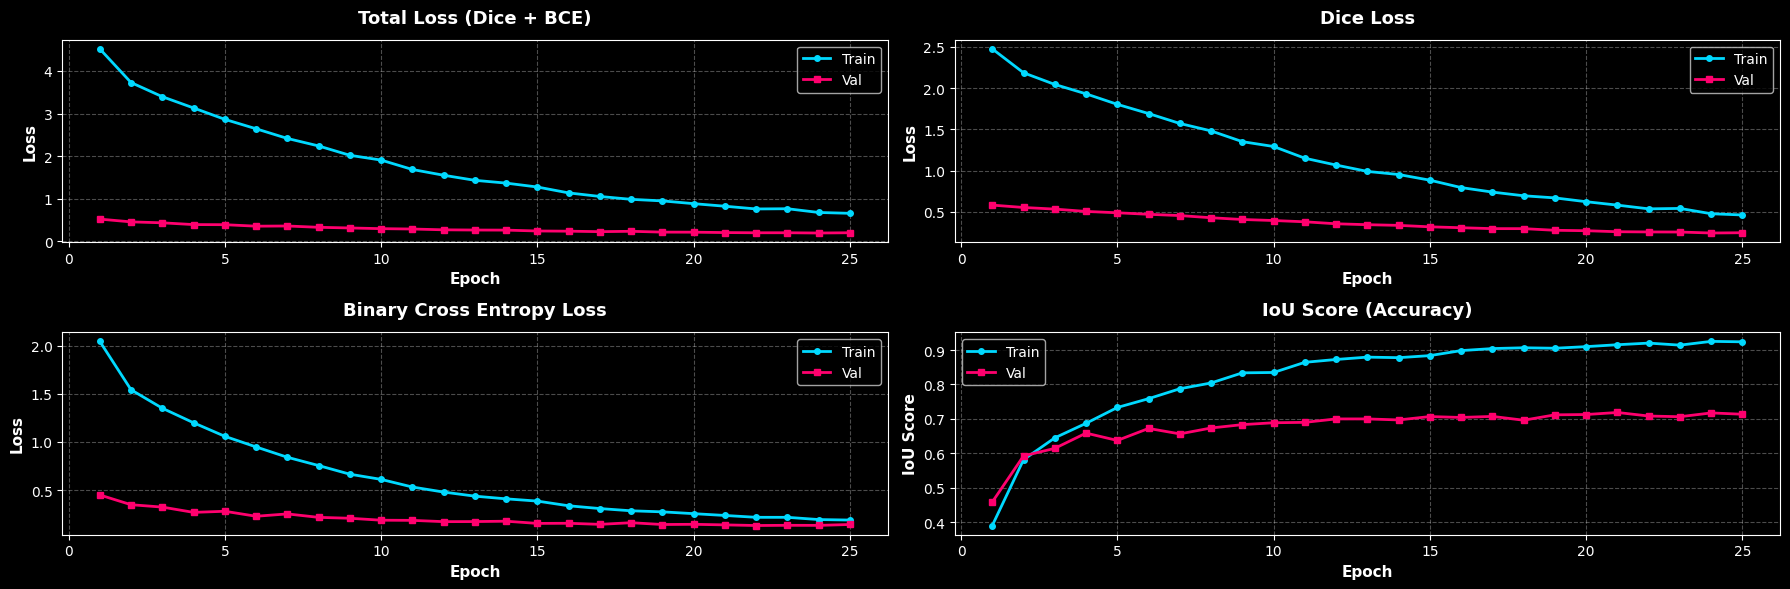

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(18, 6))

epochs_range = range(1, len(history['train_loss']) + 1)

# Total Loss
axes[0, 0].plot(epochs_range, history['train_loss'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[0, 0].plot(epochs_range, history['val_loss'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[0, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 0].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Total Loss (Dice + BCE)', fontsize=13, fontweight='bold', pad=12)
axes[0, 0].legend(fontsize=10)
axes[0, 0].grid(True, alpha=0.3, linestyle='--')

# Dice Loss
axes[0, 1].plot(epochs_range, history['train_dice'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[0, 1].plot(epochs_range, history['val_dice'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[0, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[0, 1].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[0, 1].set_title('Dice Loss', fontsize=13, fontweight='bold', pad=12)
axes[0, 1].legend(fontsize=10)
axes[0, 1].grid(True, alpha=0.3, linestyle='--')

# BCE Loss
axes[1, 0].plot(epochs_range, history['train_bce'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[1, 0].plot(epochs_range, history['val_bce'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[1, 0].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Loss', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Binary Cross Entropy Loss', fontsize=13, fontweight='bold', pad=12)
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(True, alpha=0.3, linestyle='--')

# IoU (Accuracy)
axes[1, 1].plot(epochs_range, history['train_iou'], 'o-', color='#00d9ff', linewidth=2, label='Train', markersize=4)
axes[1, 1].plot(epochs_range, history['val_iou'], 's-', color='#ff006e', linewidth=2, label='Val', markersize=4)
axes[1, 1].set_xlabel('Epoch', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('IoU Score', fontsize=11, fontweight='bold')
axes[1, 1].set_title('IoU Score (Accuracy)', fontsize=13, fontweight='bold', pad=12)
axes[1, 1].legend(fontsize=10)
axes[1, 1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'training_history_detailed.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

In [86]:
import cv2
import numpy as np

def create_overlay(rgb_img, mask, pred_mask=None, alpha=0.4):
    """Overlay where overlap is green and mismatched areas are red."""
    rgb_img = (rgb_img * 255).astype(np.uint8) if rgb_img.max() <= 1 else rgb_img.astype(np.uint8)
    if pred_mask is None:
        # Simple overlay with true mask
        overlay = rgb_img.copy()
        mask_colored = np.zeros_like(rgb_img)
        mask_colored[:, :, 1] = (mask * 255).astype(np.uint8)  # Green channel
        return cv2.addWeighted(rgb_img, 1-alpha, mask_colored, alpha, 0)
    # Binarize masks
    mask_bin = (mask > 0.5).astype(np.uint8)
    pred_bin = (pred_mask > 0.5).astype(np.uint8)
    
    overlay = rgb_img.copy()
    color_layer = np.zeros_like(rgb_img)

    # Overlap (TP): Green
    tp = (mask_bin & pred_bin)
    color_layer[tp == 1] = (0, 255, 0)
    
    # Non-overlapping (errors): Red
    error = (mask_bin ^ pred_bin)  # XOR = non-overlapping
    color_layer[error == 1] = (255, 0, 0)

    # Blend with original image
    overlay = cv2.addWeighted(rgb_img, 1 - alpha, color_layer, alpha, 0)

    return overlay




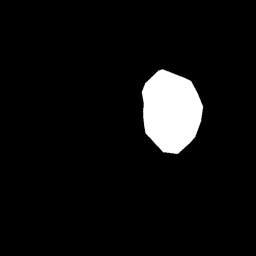
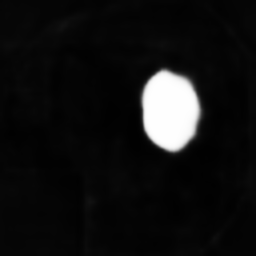
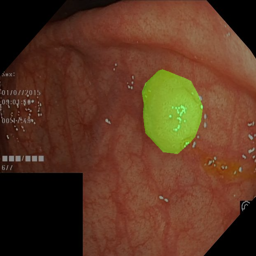
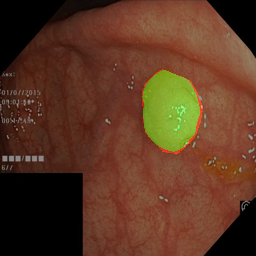

In [87]:
# # Load best model
model.load_state_dict(torch.load(MODEL_OUTPUT_DIR / "best_pranet_model.pth"))
model.eval()
# Get random images
image_paths = helper.get_images_from_dirs([INPUT_DIR, TARGET_DIR])
# Load and preprocess
img_pil = Image.open(image_paths[0]).convert('RGB')
mask_pil = Image.open(image_paths[1]).convert('L')
img_resized = img_pil.resize((HEIGHT,WIDTH))
img_tensor = torch.from_numpy(np.array(img_resized).astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
# Predict
with torch.no_grad():
    
    _, _, _, pred = model(img_tensor)
    pred = torch.sigmoid(pred)
    pred = pred.cpu().numpy()[0, 0]
# Convert for visualization
img_np = np.array(img_resized)
mask_np = np.array(mask_pil.resize((HEIGHT,WIDTH))) / 255.0
# Create overlays
overlay_true = create_overlay(img_np, mask_np)
overlay_pred = create_overlay(img_np, mask_np, pred)
# Display using helper
helper.show_grid({
    # 'RGB Image': img_np,
    'True Mask': (mask_np * 255).astype(np.uint8),
    'Predicted Mask': (pred * 255).astype(np.uint8),
    'RGB + True Mask': overlay_true,
    'RGB + Predicted': overlay_pred
}, grid="row",width=1300)

In [88]:
def evaluate_validation_set(model, val_image_dir, val_mask_dir, device, img_size=(HEIGHT,WIDTH), sample_pixels=10000):
    """
    Efficient evaluation with pixel sampling to avoid memory issues
    
    Args:
        sample_pixels: Number of pixels to sample per image for confusion matrix
    """
    model.eval()
    
    val_images = sorted(list(Path(val_image_dir).glob('*.png')) + list(Path(val_image_dir).glob('*.jpg')))
    val_masks = sorted(list(Path(val_mask_dir).glob('*.png')) + list(Path(val_mask_dir).glob('*.jpg')))
    
    # Use limited subset if too many images
    if len(val_images) > 100:
        print(f"Using 100 images for evaluation (out of {len(val_images)})")
        val_images = val_images[:100]
        val_masks = val_masks[:100]
    
    all_preds = []
    all_targets = []
    ious = []
    precisions = []
    recalls = []
    
    with torch.no_grad():
        for img_path, mask_path in tqdm(zip(val_images, val_masks), total=len(val_images), desc="Evaluating"):
            # Load and preprocess
            img = Image.open(img_path).convert('RGB').resize(img_size)
            mask = Image.open(mask_path).convert('L').resize(img_size)
            
            img_tensor = torch.from_numpy(np.array(img).astype(np.float32) / 255.0).permute(2, 0, 1).unsqueeze(0).to(device)
            mask_np = np.array(mask) / 255.0
            
            # Predict
            _, _, _, pred = model(img_tensor)
            pred = torch.sigmoid(pred)
            pred = pred.cpu().numpy()[0, 0]
            
            pred = pred.squeeze()  # (H, W)
            
            # Binary masks
            pred_bin = (pred > 0.5).astype(np.uint8)
            mask_bin = (mask_np > 0.5).astype(np.uint8)
            
            # Sample pixels randomly to avoid memory issues
            h, w = pred_bin.shape
            total_pixels = h * w
            
            if total_pixels > sample_pixels:
                # Random sampling
                indices = np.random.choice(total_pixels, sample_pixels, replace=False)
                pred_flat = pred_bin.flatten()[indices]
                mask_flat = mask_bin.flatten()[indices]
            else:
                pred_flat = pred_bin.flatten()
                mask_flat = mask_bin.flatten()
            
            all_preds.extend(pred_flat)
            all_targets.extend(mask_flat)
            
            # Calculate per-image metrics
            intersection = (pred_bin * mask_bin).sum()
            union = pred_bin.sum() + mask_bin.sum() - intersection
            iou = intersection / (union + 1e-6)
            ious.append(iou)
            
            # Per-image precision and recall
            tp = (pred_bin * mask_bin).sum()
            fp = (pred_bin * (1 - mask_bin)).sum()
            fn = ((1 - pred_bin) * mask_bin).sum()
            
            precision = tp / (tp + fp + 1e-6)
            recall = tp / (tp + fn + 1e-6)
            
            precisions.append(precision)
            recalls.append(recall)
    
    # Convert to numpy for faster computation
    all_preds = np.array(all_preds, dtype=np.uint8)
    all_targets = np.array(all_targets, dtype=np.uint8)
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    precision = np.mean(precisions)
    recall = np.mean(recalls)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-6)
    mean_iou = np.mean(ious)
    
    cm = confusion_matrix(all_targets, all_preds)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mean_iou': mean_iou,
        'confusion_matrix': cm,
        'n_images': len(val_images)
    }


Using 100 images for evaluation (out of 1000)


Evaluating: 100%|██████████| 100/100 [00:02<00:00, 41.53it/s]



METRICS ON TRAINING DATASET==================================================
VALIDATION METRICS
Pixel Accuracy:  0.9738
Precision:       0.9049
Recall:          0.8850
F1 Score:        0.8949
Mean IoU:        0.8108


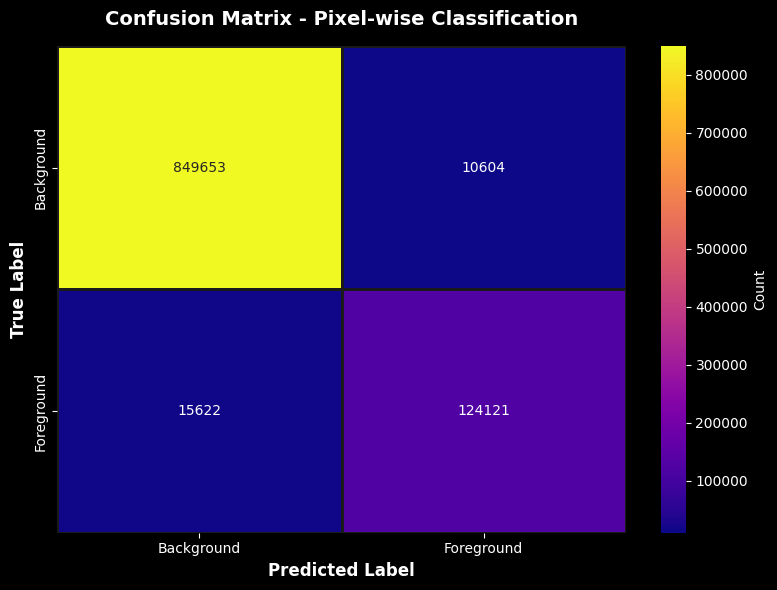

In [89]:
# Evaluate on validation set
metrics = evaluate_validation_set(model, INPUT_DIR, TARGET_DIR, device)

# Print metrics
print("\nMETRICS ON TRAINING DATASET" + "="*50)
print("VALIDATION METRICS")
print("="*50)
print(f"Pixel Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision:       {metrics['precision']:.4f}")
print(f"Recall:          {metrics['recall']:.4f}")
print(f"F1 Score:        {metrics['f1']:.4f}")
print(f"Mean IoU:        {metrics['mean_iou']:.4f}")
print("="*50)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='plasma', 
            xticklabels=['Background', 'Foreground'], 
            yticklabels=['Background', 'Foreground'],
            cbar_kws={'label': 'Count'},
            ax=ax, linewidths=2, linecolor='#1a1a1a')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Pixel-wise Classification', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()

Using 100 images for evaluation (out of 196)


Evaluating: 100%|██████████| 100/100 [00:02<00:00, 43.34it/s]



METRICS ON VALIDATION DATASET==================================================
VALIDATION METRICS
Pixel Accuracy:  0.9807
Precision:       0.8522
Recall:          0.8333
F1 Score:        0.8426
Mean IoU:        0.7325


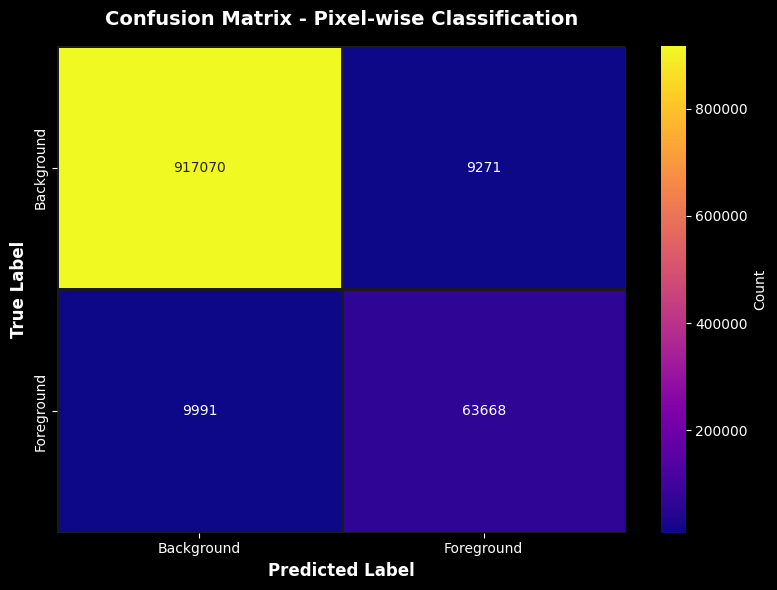

In [ ]:
VAL_DIR = BASE_DIR / "data" / "raw" / "kvasir-sessile" / "sessile-main-Kvasir-SEG"
VAL_INPUT_DIR = VAL_DIR / "images"
VAL_MASK_DIR = VAL_DIR / "masks"
# Evaluate on validation set
metrics = evaluate_validation_set(model, VAL_INPUT_DIR, VAL_MASK_DIR, device)

# Print metrics
print("\nMETRICS ON VALIDATION DATASET" + "="*50)
print("VALIDATION METRICS")
print("="*50)
print(f"Pixel Accuracy:  {metrics['accuracy']:.4f}")
print(f"Precision:       {metrics['precision']:.4f}")
print(f"Recall:          {metrics['recall']:.4f}")
print(f"F1 Score:        {metrics['f1']:.4f}")
print(f"Mean IoU:        {metrics['mean_iou']:.4f}")
print("="*50)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='plasma', 
            xticklabels=['Background', 'Foreground'], 
            yticklabels=['Background', 'Foreground'],
            cbar_kws={'label': 'Count'},
            ax=ax, linewidths=2, linecolor='#1a1a1a')

ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
ax.set_title('Confusion Matrix - Pixel-wise Classification', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor='#1a1a1a')
plt.show()